In [4]:
# Step 1: Import Required Liabraries 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, classification_report
import tkinter as tk
from tkinter import messagebox
import joblib

In [5]:
# Step 2: Data Cleaning

# Load dataset
df = pd.read_csv("covid.csv")

print("Initial shape:", df.shape)
df.head()



Initial shape: (321, 6)


,Date,State,Region,Confirmed,Deaths,Recovered
0,4/29/2020,NaN,Afghanistan,1939,60,252
1,4/29/2020,NaN,Albania,766,30,455
2,4/29/2020,NaN,Algeria,3848,444,1702
3,4/29/2020,NaN,Andorra,743,42,423
4,4/29/2020,NaN,Angola,27,2,7


In [6]:
# Basic info and missing values
df.info()
print("\nMissing values:\n", df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 321 entries, 0 to 320
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Date       321 non-null    object
 1   State      140 non-null    object
 2   Region     321 non-null    object
 3   Confirmed  321 non-null    int64 
 4   Deaths     321 non-null    int64 
 5   Recovered  321 non-null    int64 
dtypes: int64(3), object(3)
memory usage: 15.2+ KB

Missing values:
 Date           0
State        181
Region         0
Confirmed      0
Deaths         0
Recovered      0
dtype: int64


In [7]:
# Cleaning process
# Strip spaces from column names
df.columns = df.columns.str.strip()

# Remove duplicates
df = df.drop_duplicates()

# Fill missing values
df = df.fillna({
    col: 'Unknown' if df[col].dtype == 'O' else 0
    for col in df.columns
})

print("After cleaning:", df.shape)

# Save cleaned data for Power BI
df.to_csv("covid_cleaned_for_powerbi.csv", index=False)
print("✅ Cleaned CSV saved as covid_cleaned_for_powerbi.csv")


After cleaning: (321, 6)
✅ Cleaned CSV saved as covid_cleaned_for_powerbi.csv


,Date,State,Region,Confirmed,Deaths,Recovered
count,321,321,321,321.000000,321.000000,321.000000
unique,1,138,187,NaN,NaN,NaN
top,4/29/2020,Unknown,US,NaN,NaN,NaN
freq,321,181,58,NaN,NaN,NaN
mean,NaN,NaN,NaN,9949.800623,709.152648,3030.277259
std,NaN,NaN,NaN,31923.853086,3236.162817,14364.870365
min,NaN,NaN,NaN,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,104.000000,2.000000,2.000000
50%,NaN,NaN,NaN,653.000000,12.000000,73.000000
75%,NaN,NaN,NaN,4655.000000,144.000000,587.000000


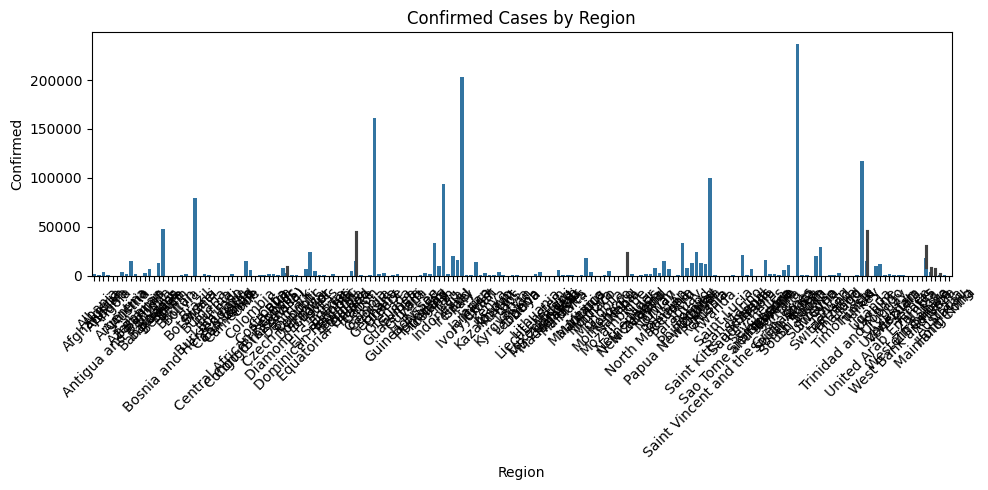

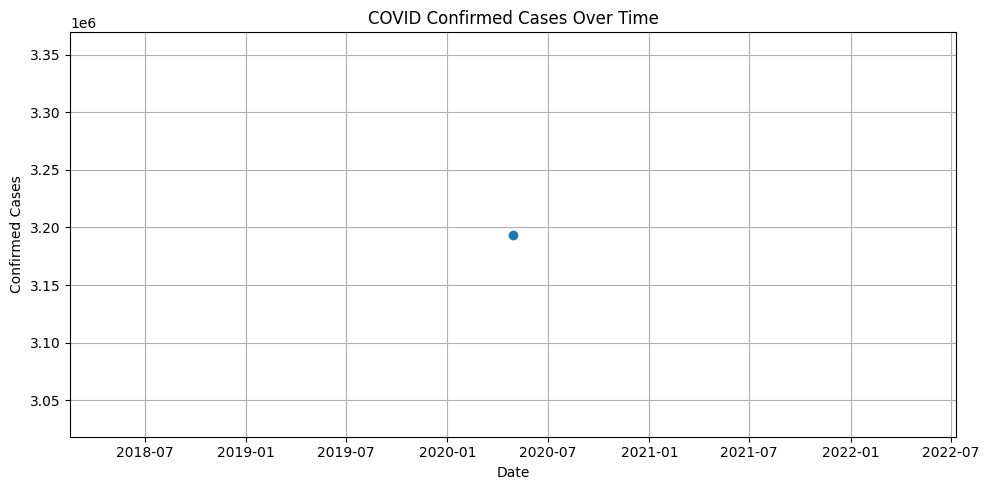

In [8]:
# Step 4: EDA & Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Show summary stats
display(df.describe(include='all'))

# Example 1: Confirmed cases by Region (if available)
if 'Region' in df.columns and 'Confirmed' in df.columns:
    plt.figure(figsize=(10,5))
    sns.barplot(x='Region', y='Confirmed', data=df)
    plt.xticks(rotation=45)
    plt.title("Confirmed Cases by Region")
    plt.tight_layout()
    plt.savefig("confirmed_by_region.png")
    plt.show()

# Example 2: Trend over time (if Date column available)
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    daily = df.groupby('Date')['Confirmed'].sum().reset_index()
    plt.figure(figsize=(10,5))
    plt.plot(daily['Date'], daily['Confirmed'], marker='o')
    plt.title("COVID Confirmed Cases Over Time")
    plt.xlabel("Date")
    plt.ylabel("Confirmed Cases")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("confirmed_time_series.png")
    plt.show()


In [9]:
# Step 5: Demo ML Model on Synthetic Data

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np
import joblib

# Create a synthetic dataset for demonstration
np.random.seed(42)
synthetic = pd.DataFrame({
    'age': np.random.randint(18, 70, 1000),
    'fever': np.random.randint(0, 2, 1000),
    'cough': np.random.randint(0, 2, 1000),
    'breathlessness': np.random.randint(0, 2, 1000),
    'contact_with_positive': np.random.randint(0, 2, 1000),
})

# Rule to simulate 'COVID positive' label
synthetic['covid_label'] = (
    (synthetic['fever'] + synthetic['cough'] + synthetic['contact_with_positive']) > 1
).astype(int)

# Train-test split
X = synthetic.drop('covid_label', axis=1)
y = synthetic['covid_label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print("Model Accuracy:", accuracy_score(y_test, y_pred))

# Save model
joblib.dump(model, "covid_demo_model.joblib")
print("✅ Model saved as covid_demo_model.joblib")


Model Accuracy: 1.0
✅ Model saved as covid_demo_model.joblib


In [10]:
# Step 6: Tkinter App for COVID Prediction

import tkinter as tk
from tkinter import messagebox
import joblib

# Load trained model
model = joblib.load("covid_demo_model.joblib")

def predict_covid():
    try:
        age = float(entry_age.get())
        fever = int(entry_fever.get())
        cough = int(entry_cough.get())
        breath = int(entry_breath.get())
        contact = int(entry_contact.get())

        data = [[age, fever, cough, breath, contact]]
        pred = model.predict(data)[0]
        prob = model.predict_proba(data)[0][1]

        result = "🟢 No COVID detected" if pred == 0 else "🔴 COVID Positive"
        messagebox.showinfo("Prediction Result", f"{result}\nProbability: {prob:.2f}")

    except Exception as e:
        messagebox.showerror("Error", f"Invalid input: {e}")

# GUI window
root = tk.Tk()
root.title("COVID Prediction System")
root.geometry("350x350")

tk.Label(root, text="Age:").pack()
entry_age = tk.Entry(root); entry_age.pack()

tk.Label(root, text="Fever (0/1):").pack()
entry_fever = tk.Entry(root); entry_fever.pack()

tk.Label(root, text="Cough (0/1):").pack()
entry_cough = tk.Entry(root); entry_cough.pack()

tk.Label(root, text="Breathlessness (0/1):").pack()
entry_breath = tk.Entry(root); entry_breath.pack()

tk.Label(root, text="Contact With Positive (0/1):").pack()
entry_contact = tk.Entry(root); entry_contact.pack()

tk.Button(root, text="Predict", command=predict_covid, bg="lightgreen").pack(pady=10)
root.mainloop()


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation

In [12]:
# Step 7: Power BI Integration

df.to_csv("covid_cleaned_for_powerbi.csv", index=False)
print("Power BI file saved: covid_cleaned_data.csv")

Power BI file saved: covid_cleaned_data.csv


In [13]:
df.columns 

Index(['Date', 'State', 'Region', 'Confirmed', 'Deaths', 'Recovered'], dtype='object')